In [ ]:
!pip3 install arch
!pip3 install py_vollib
from py_vollib.black_scholes import black_scholes as bs
from py_vollib.black_scholes.greeks.analytical import delta, gamma, vega, theta, rho
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.stats import norm
from arch import arch_model
import warnings

# Define tickers and date range
tickers = {
    'Maruti Suzuki': 'MARUTI.NS',
    'DAM Capital Advisories': 'DAMCAPITAL.NS',
    'Nifty 50': '^NSEI',
    'JPY/INR': 'JPYINR=X',
    'Gold': 'GC=F'
}

start_date = '2020-08-09'
end_date = '2025-01-19'

# Download data using 'Close' prices to avoid missing 'Adj Close'
raw_data = yf.download(list(tickers.values()), start=start_date, end=end_date)
data = raw_data['Close']
data.columns = tickers.keys()


# Drop rows where all values are NaN
data = data.dropna(how='all')

# Forward fill and back fill to handle missing values
# Forward fill and back fill to handle missing values
data.ffill(inplace=True)
data.bfill(inplace=True)


[*********************100%***********************]  5 of 5 completed



Summary Statistics:
                             Mean   Std Dev   Skewness    Kurtosis
Maruti Suzuki          -0.000176  0.005448 -11.724928  239.557273
DAM Capital Advisories  0.000262  0.009366  -0.610040    2.603694
Nifty 50               -0.000198  0.007767   0.113271    3.417311
JPY/INR                 0.000559  0.014790   0.258140    3.571014
Gold                    0.000623  0.008972  -0.594515    4.261388


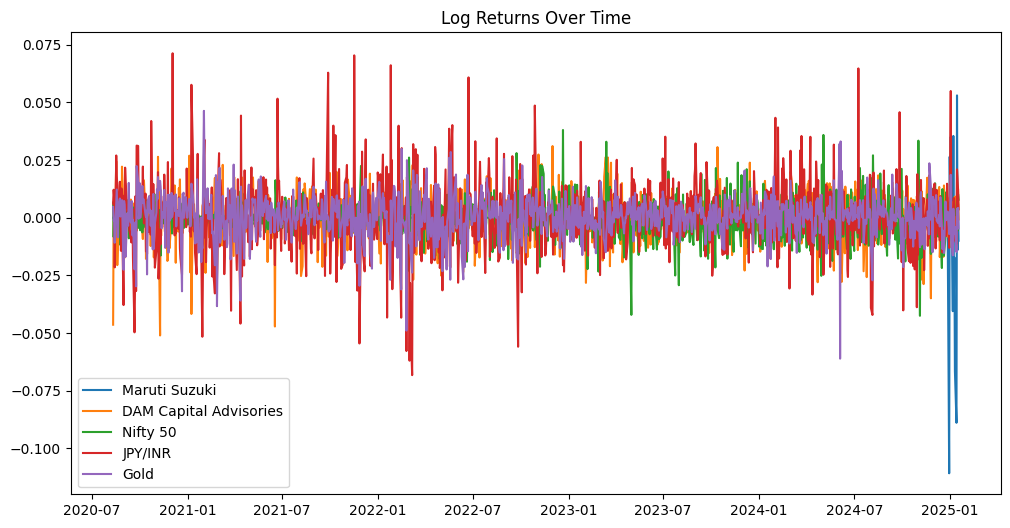

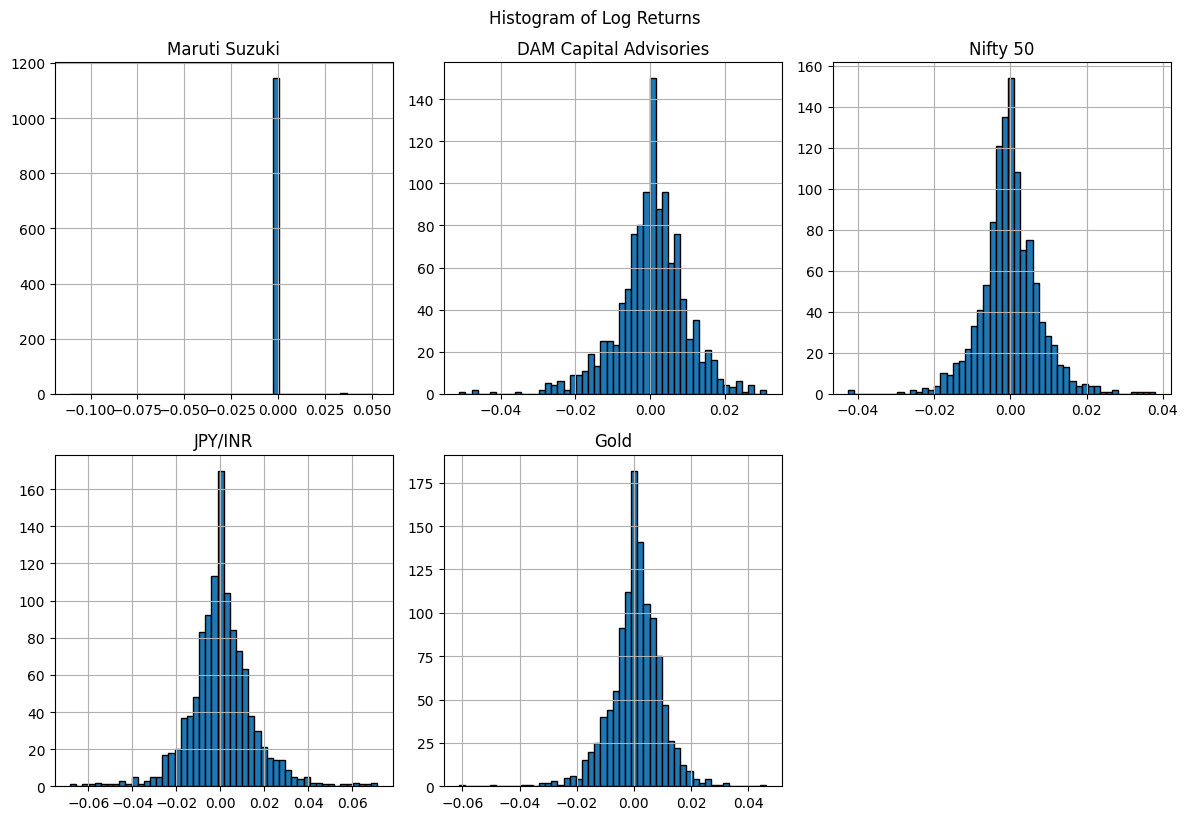

In [ ]:
# ================================
# STEPS 1 AND 2: Asset Selection & Data Cleaning
# ================================

# Compute log returns
log_returns = np.log(data / data.shift(1)).dropna()

# Summary statistics
summary_stats = pd.DataFrame({
    'Mean': log_returns.mean(),
    'Std Dev': log_returns.std(),
    'Skewness': log_returns.apply(skew),
    'Kurtosis': log_returns.apply(kurtosis)
})

summary_stats.columns = ['Mean', 'Std Dev', 'Skewness', 'Kurtosis']
print("\nSummary Statistics:\n", summary_stats)

# Plot line charts of log returns
plt.figure(figsize=(12, 6))
for col in log_returns.columns:
    plt.plot(log_returns[col], label=col)
plt.title('Log Returns Over Time')
plt.legend()
plt.show()

# Plot histograms
log_returns.hist(bins=50, figsize=(12, 8), layout=(2, 3), edgecolor='black')
plt.tight_layout()
plt.suptitle("Histogram of Log Returns", y=1.02)
plt.show()


In [ ]:
# Export to Excel
with pd.ExcelWriter('FRAM_assignment_data.xlsx') as writer:
    data.to_excel(writer, sheet_name='Price Data')
    log_returns.to_excel(writer, sheet_name='Log Returns')
    summary_stats.to_excel(writer, sheet_name='Summary Stats')

print("Steps 1 and 2 completed. Excel file saved as 'FRAM_assignment_data.xlsx'")

Steps 1 and 2 completed. Excel file saved as 'FRAM_assignment_data.xlsx'


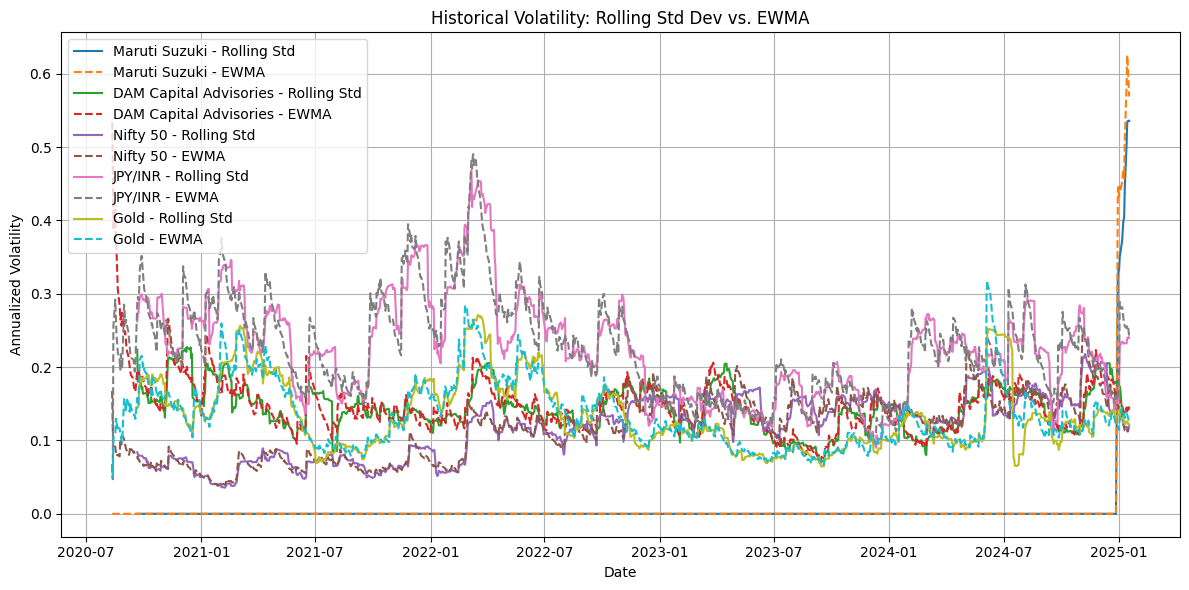

In [ ]:
# ================================
# STEP 3: Volatility Modelling
# ================================

warnings.filterwarnings('ignore')

# Historical Volatility - Rolling Std and EWMA (already covered)
rolling_volatility = log_returns.rolling(window=30).std() * np.sqrt(252)
ewm_volatility = log_returns.ewm(span=30).std() * np.sqrt(252)
# Plot Historical Volatility Methods
plt.figure(figsize=(12, 6))
for col in log_returns.columns:
    plt.plot(rolling_volatility[col], label=f"{col} - Rolling Std")
    plt.plot(ewm_volatility[col], linestyle='--', label=f"{col} - EWMA")
plt.title("Historical Volatility: Rolling Std Dev vs. EWMA")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === GARCH Modeling Section ===
# Equal-Weighted Portfolio
weights = np.array([0.2]*5)
portfolio_returns = log_returns.dot(weights)

# Function to fit GARCH models and return results
def fit_garch_models(series, name):
    results = {}

    # GARCH(1,1)
    model_garch = arch_model(series * 100, vol='Garch', p=1, q=1, rescale=False)
    res_garch = model_garch.fit(disp='off')

    # EGARCH(1,1)
    model_egarch = arch_model(series * 100, vol='EGARCH', p=1, q=1, rescale=False)
    res_egarch = model_egarch.fit(disp='off')

    # Store AIC, BIC, and Forecast
    results['Asset'] = name
    results['GARCH AIC'] = res_garch.aic
    results['GARCH BIC'] = res_garch.bic
    results['EGARCH AIC'] = res_egarch.aic
    results['EGARCH BIC'] = res_egarch.bic

    # 30-day volatility forecast (mean of forecasted variances)
    forecast_garch = res_garch.forecast(horizon=30)
    forecast_egarch = res_egarch.forecast(horizon=1)

    vol_garch = np.sqrt(forecast_garch.variance.values[-1]).mean()
    vol_egarch = np.sqrt(forecast_egarch.variance.values[-1][0])

    results['GARCH Forecast Vol (%)'] = vol_garch
    results['EGARCH Forecast Vol (%)'] = vol_egarch

    return results

# Run for all assets + portfolio
garch_results = []
for col in log_returns.columns:
    garch_results.append(fit_garch_models(log_returns[col], col))

# Portfolio modeling
garch_results.append(fit_garch_models(portfolio_returns, 'Equal-Weighted Portfolio'))

In [ ]:
# Convert to DataFrame and export
garch_df = pd.DataFrame(garch_results)
print("\nGARCH & EGARCH Model Summary:\n", garch_df)

# Save to Excel
garch_df.to_excel('fram_step3_garch_models.xlsx', index=False)
print("Step 3 completed. GARCH model output saved to 'fram_step3_garch_models.xlsx'")


GARCH & EGARCH Model Summary:
                       Asset    GARCH AIC    GARCH BIC   EGARCH AIC  \
0             Maruti Suzuki   740.655821   760.880522  -959.551328   
1    DAM Capital Advisories  3120.733349  3140.958050  3119.512027   
2                  Nifty 50  2526.977174  2547.201876  2526.020205   
3                   JPY/INR  4139.263581  4159.488282  4141.243525   
4                      Gold  2922.101653  2942.326354  2926.534146   
5  Equal-Weighted Portfolio  1654.728337  1674.953038  1655.449381   

    EGARCH BIC  GARCH Forecast Vol (%)  EGARCH Forecast Vol (%)  
0  -939.326627                2.826103                 9.048077  
1  3139.736728                0.892794                 0.920162  
2  2546.244906                0.981842                 0.973573  
3  4161.468226                1.449357                 1.510474  
4  2946.758847                0.861808                 0.836568  
5  1675.674082                0.567872                 0.838432  
Step 3 complete

In [ ]:
# ================================
# STEP 4: Value At Risk (VaR)
# ================================

import numpy as np
from scipy.stats import norm

# Parameters
confidence_levels = [0.95, 0.99]
z_scores = {0.95: norm.ppf(1 - 0.95), 0.99: norm.ppf(1 - 0.99)}

# -------------------------------
# VARIANCE-COVARIANCE METHOD
# -------------------------------
print("\n--- Variance-Covariance VaR ---")

for col in log_returns.columns:
    mu = log_returns[col].mean()
    sigma = log_returns[col].std()
    print(f"\n{col}:")

    for cl in confidence_levels:
        z = -z_scores[cl]
        var_1d = -(mu + z * sigma)
        var_10d = -(10 * mu + z * np.sqrt(10) * sigma)

        print(f"  {int(cl * 100)}% 1-day VaR (VC): {var_1d:.5f}")
        print(f"  {int(cl * 100)}% 10-day VaR (VC): {var_10d:.5f}")

# -------------------------------
# HISTORICAL SIMULATION METHOD
# -------------------------------
print("\n--- Historical Simulation VaR ---")

for col in log_returns.columns:
    returns = log_returns[col].dropna()
    print(f"\n{col}:")

    for cl in confidence_levels:
        var_1d = -np.percentile(returns, (1 - cl) * 100)
        simulated_10d_returns = [np.sum(np.random.choice(returns, size=10)) for _ in range(10000)]
        var_10d = -np.percentile(simulated_10d_returns, (1 - cl) * 100)

        print(f"  {int(cl * 100)}% 1-day VaR (Historical): {var_1d:.5f}")
        print(f"  {int(cl * 100)}% 10-day VaR (Historical): {var_10d:.5f}")

# -------------------------------
# MONTE CARLO SIMULATION METHOD
# -------------------------------
print("\n--- Monte Carlo Simulation VaR ---")

np.random.seed(42)  # For reproducibility
simulations = 10000

for col in log_returns.columns:
    mu = log_returns[col].mean()
    sigma = log_returns[col].std()
    print(f"\n{col}:")

    for cl in confidence_levels:
        z = -z_scores[cl]

        # 1-day
        simulated_1d_returns = np.random.normal(mu, sigma, simulations)
        var_1d = -np.percentile(simulated_1d_returns, (1 - cl) * 100)

        # 10-day
        simulated_10d_returns = np.random.normal(mu * 10, sigma * np.sqrt(10), simulations)
        var_10d = -np.percentile(simulated_10d_returns, (1 - cl) * 100)

        print(f"  {int(cl * 100)}% 1-day VaR (Monte Carlo): {var_1d:.5f}")
        print(f"  {int(cl * 100)}% 10-day VaR (Monte Carlo): {var_10d:.5f}")

print("Step 4 completed.")

# ================================
# STEP 5: Backtesting & Model Validation
# ================================

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import chi2

# Set confidence level for backtesting
backtest_conf_level = 0.99
z_99 = norm.ppf(1 - backtest_conf_level)

# Use last 250 observations for backtesting
backtest_window = 250
log_returns_bt = log_returns[-backtest_window:]

print("\n=== STEP 5: BACKTESTING 1-DAY 99% VAR ===\n")

for col in log_returns_bt.columns:
    # Historical stats
    mu = log_returns_bt[col].mean()
    sigma = log_returns_bt[col].std()

    # Compute 1-day 99% parametric VaR
    var_99 = -(mu + z_99 * sigma)

    # Compare actual returns to VaR
    returns = log_returns_bt[col]
    exceptions = returns[returns < -var_99]
    num_exceptions = len(exceptions)
    T = len(returns)
    p = 1 - backtest_conf_level
    expected = T * p

    print(f"\nAsset: {col}")
    print(f"Expected exceptions: {expected:.2f}")
    print(f"Actual exceptions: {num_exceptions}")

    # === Kupiec Test ===
    failure_ratio = num_exceptions / T
    kupiec_stat = -2 * (np.log((1 - p)**(T - num_exceptions) * p**num_exceptions) -
                        np.log((1 - failure_ratio)**(T - num_exceptions) * failure_ratio**num_exceptions))
    kupiec_p = 1 - chi2.cdf(kupiec_stat, df=1)
    print(f"Kupiec Test p-value: {kupiec_p:.4f} → {'Reject' if kupiec_p < 0.05 else 'Accept'} model")

    # === Christoffersen Test ===
    # Convert returns to binary exception sequence
    exceptions_seq = (returns < -var_99).astype(int).values
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(exceptions_seq)):
        if exceptions_seq[i-1] == 0 and exceptions_seq[i] == 0:
            n00 += 1
        elif exceptions_seq[i-1] == 0 and exceptions_seq[i] == 1:
            n01 += 1
        elif exceptions_seq[i-1] == 1 and exceptions_seq[i] == 0:
            n10 += 1
        elif exceptions_seq[i-1] == 1 and exceptions_seq[i] == 1:
            n11 += 1

    pi0 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi1 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    L0 = ((1 - pi)**(n00 + n10)) * (pi**(n01 + n11))
    L1 = ((1 - pi0)**n00) * (pi0**n01) * ((1 - pi1)**n10) * (pi1**n11)
    christ_stat = -2 * np.log(L0 / L1) if L0 > 0 and L1 > 0 else 0
    christ_p = 1 - chi2.cdf(christ_stat, df=1)

    print(f"Christoffersen Test p-value: {christ_p:.4f} → {'Reject' if christ_p < 0.05 else 'Accept'} model")

    # === Ljung-Box Test on GARCH(1,1) residuals ===
    # Refit GARCH(1,1) model on the 250-day data
    model = arch_model(returns * 100, vol='GARCH', p=1, q=1, rescale=False)
    res = model.fit(disp='off')
    lb_test = acorr_ljungbox(res.std_resid.dropna(), lags=[10], return_df=True)

    p_val_lb = lb_test['lb_pvalue'].values[0]
    print(f"Ljung-Box Test p-value (lag=10): {p_val_lb:.4f} → {'Reject' if p_val_lb < 0.05 else 'Accept'} model")

print("Step 5 completed.")



--- Variance-Covariance VaR ---

Maruti Suzuki:
  95% 1-day VaR (VC): -0.00879
  95% 10-day VaR (VC): -0.02658
  99% 1-day VaR (VC): -0.01250
  99% 10-day VaR (VC): -0.03832

DAM Capital Advisories:
  95% 1-day VaR (VC): -0.01567
  95% 10-day VaR (VC): -0.05134
  99% 1-day VaR (VC): -0.02205
  99% 10-day VaR (VC): -0.07152

Nifty 50:
  95% 1-day VaR (VC): -0.01258
  95% 10-day VaR (VC): -0.03842
  99% 1-day VaR (VC): -0.01787
  99% 10-day VaR (VC): -0.05516

JPY/INR:
  95% 1-day VaR (VC): -0.02489
  95% 10-day VaR (VC): -0.08252
  99% 1-day VaR (VC): -0.03497
  99% 10-day VaR (VC): -0.11439

Gold:
  95% 1-day VaR (VC): -0.01538
  95% 10-day VaR (VC): -0.05289
  99% 1-day VaR (VC): -0.02150
  99% 10-day VaR (VC): -0.07223

--- Historical Simulation VaR ---

Maruti Suzuki:
  95% 1-day VaR (Historical): -0.00000
  95% 10-day VaR (Historical): 0.01040
  99% 1-day VaR (Historical): -0.00000
  99% 10-day VaR (Historical): 0.11084

DAM Capital Advisories:
  95% 1-day VaR (Historical): 0.0160

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


Estimation of Greeks using py_vollib library

In [ ]:
# Parameters using py_vollib library
S = 11900      # Spot price
K = 11600        # Strike price
t = 17 / 365  # Time to expiration in years
r = 0.0676     # Risk-free interest rate
sigma = 0.25  # Volatility
num_simulations = 10000
flag = 'c'    # 'c' for call, 'p' for put

# Option price
call_price = bs(flag, S, K, t, r, sigma)
print("Call Price:", round(call_price, 4))

# Greeks
print("Delta:", round(delta(flag, S, K, t, r, sigma), 4))
print("Gamma:", round(gamma(flag, S, K, t, r, sigma), 4))
print("Vega:", round(vega(flag, S, K, t, r, sigma), 4))
print("Theta:", round(theta(flag, S, K, t, r, sigma), 4))
print("Rho:", round(rho(flag, S, K, t, r, sigma), 4))

Call Price: 455.5678
Delta: 0.7118
Gamma: 0.0005
Vega: 8.7656
Theta: -7.9296
Rho: 3.7328


Simulation Of GBM paths

In [ ]:
# === 1. Simulate GBM paths ===
np.random.seed(42)
Z = np.random.normal(0, 1, num_simulations)
ST = S * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

# === 2. Calculate European Call and Put Prices ===
call_payoffs = np.maximum(ST - K, 0)
put_payoffs = np.maximum(K - ST, 0)

call_price = np.exp(-r * T) * np.mean(call_payoffs)
put_price = np.exp(-r * T) * np.mean(put_payoffs)

print("\n=== STEP 6: OPTION PRICING ===")
print(f"European Call Option Price (ATM): ₹{call_price:.2f}")
print(f"European Put Option Price (ATM): ₹{put_price:.2f}")

# === 3. Calculate Greeks using Black-Scholes ===
d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

N_d1 = norm.cdf(d1)
N_d2 = norm.cdf(d2)



=== STEP 6: OPTION PRICING ===
European Call Option Price (ATM): ₹8904.44
European Put Option Price (ATM): ₹0.00


Greeks value at ATM

In [ ]:
# Greeks
delta = N_d1
gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
vega = S * norm.pdf(d1) * np.sqrt(T)
theta = (-S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * N_d2

print("\n=== GREEK SENSITIVITIES (ATM Call) ===")
print(f"Delta: {delta:.4f}")
print(f"Gamma: {gamma:.6f}")
print(f"Vega: {vega:.2f}")
print(f"Theta: {theta:.2f}")


=== GREEK SENSITIVITIES (ATM Call) ===
Delta: 1.0000
Gamma: 0.000000
Vega: 0.00
Theta: -0.00


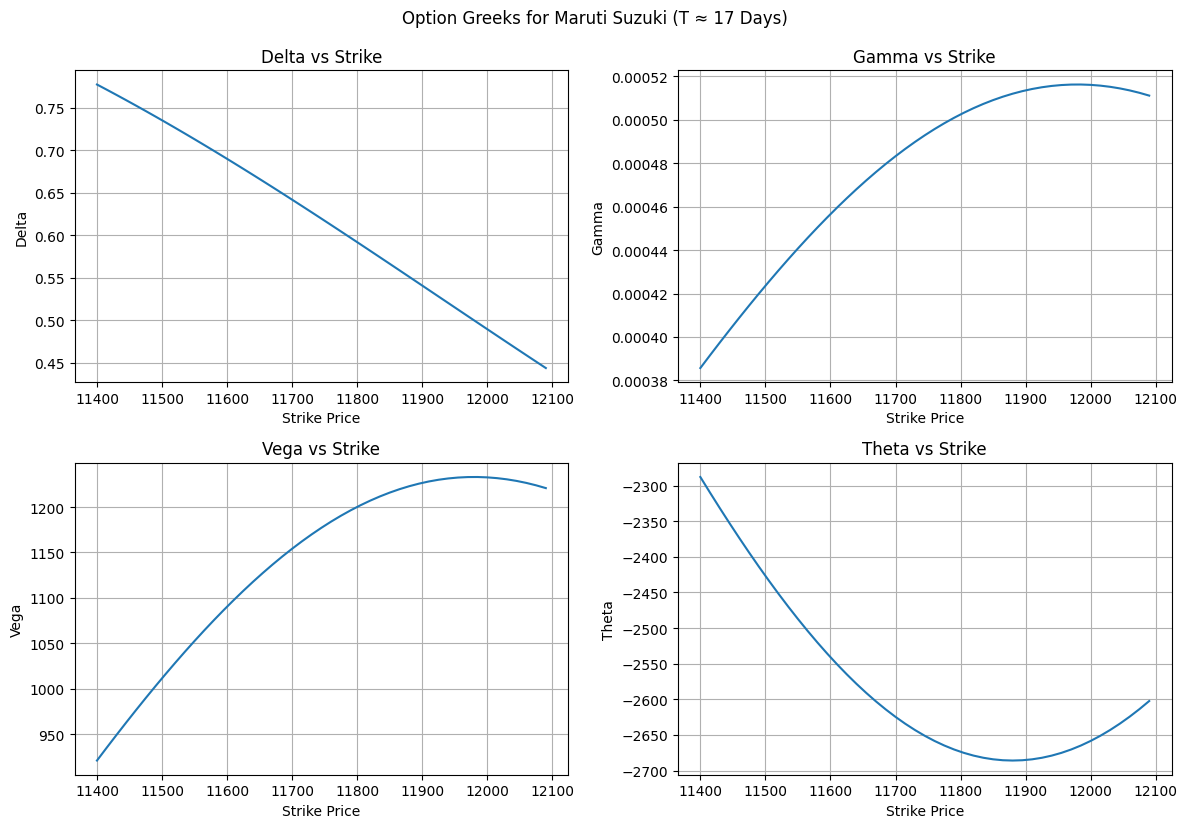

Step 6 completed.


In [ ]:
# === 4. Greeks across different strikes ===
strikes = np.arange(11400, 12100, 15)
d1_vals = (np.log(S / strikes) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2_vals = d1_vals - sigma * np.sqrt(T)

delta_vals = norm.cdf(d1_vals)
gamma_vals = norm.pdf(d1_vals) / (S * sigma * np.sqrt(T))
vega_vals = S * norm.pdf(d1_vals) * np.sqrt(T)
theta_vals = (-S * norm.pdf(d1_vals) * sigma) / (2 * np.sqrt(T)) - r * strikes * np.exp(-r * T) * norm.cdf(d2_vals)

# === 5. Plot Greek Sensitivities ===
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(strikes, delta_vals)
plt.title("Delta vs Strike")
plt.xlabel("Strike Price")
plt.ylabel("Delta")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(strikes, gamma_vals)
plt.title("Gamma vs Strike")
plt.xlabel("Strike Price")
plt.ylabel("Gamma")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(strikes, vega_vals)
plt.title("Vega vs Strike")
plt.xlabel("Strike Price")
plt.ylabel("Vega")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(strikes, theta_vals)
plt.title("Theta vs Strike")
plt.xlabel("Strike Price")
plt.ylabel("Theta")
plt.grid(True)

plt.tight_layout()
plt.suptitle("Option Greeks for Maruti Suzuki (T ≈ 17 Days)", y=1.03)
plt.show()
print("Step 6 completed.")

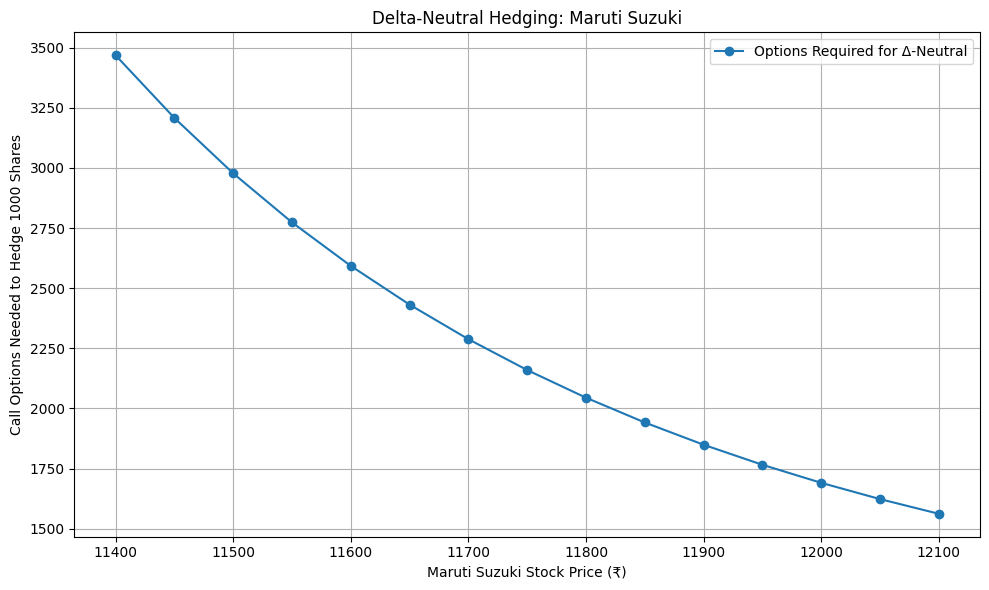


=== DELTA-NEUTRAL HEDGE EXAMPLE ===
At Stock Price ₹11400, we need 3468.66 call options to hedge 1000 shares.
At Stock Price ₹11650, we need 2431.52 call options to hedge 1000 shares.
At Stock Price ₹11900, we need 1848.78 call options to hedge 1000 shares.


In [ ]:
# ================================
# STEP 7: DELTA-NEUTRAL HEDGING
# ================================

from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# === Assumptions ===
shares_held = 1000
S_range = np.linspace(11400,12100, 15)  # Range of stock prices for simulation
K = 11900                              # Strike price (ATM)
r = 0.0676                             # Risk-free rate
sigma = 0.25                           # Annual volatility
T = 17 / 252                           # Time to maturity (17 trading days)

# === Calculate Delta for each simulated stock price ===
def call_delta(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

deltas = call_delta(S_range, K, T, r, sigma)

# === Number of options to hedge 1000 shares ===
# Delta of 1 option = option's delta × 100 (contract size)
# We'll assume 1 option contract = 1 share for simplicity (modify if exchange-specific)
options_needed = shares_held / deltas

# === Plot the hedge ratio ===
plt.figure(figsize=(10, 6))
plt.plot(S_range, options_needed, marker='o', label='Options Required for Δ-Neutral')
plt.title('Delta-Neutral Hedging: Maruti Suzuki')
plt.xlabel('Maruti Suzuki Stock Price (₹)')
plt.ylabel('Call Options Needed to Hedge 1000 Shares')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Interpretation ===
print("\n=== DELTA-NEUTRAL HEDGE EXAMPLE ===")
for i in range(0, len(S_range), 5):
    print(f"At Stock Price ₹{S_range[i]:.0f}, we need {options_needed[i]:.2f} call options to hedge 1000 shares.")

import pandas as pd

# === Export Delta-Neutral Hedge Table to Excel ===
hedge_df = pd.DataFrame({
    'Stock Price (₹)': S_range,
    'Call Option Delta': deltas,
    'Options Needed for Δ-Neutral': options_needed
})


In [ ]:
# Save to Excel
hedge_df.to_excel('FRAM_step7_delta_hedge.xlsx', index=False)
print("Step 7 completed. Delta-Neutral Hedge table exported to 'FRAM_step7_delta_hedge.xlsx'")


Step 7 completed. Delta-Neutral Hedge table exported to 'FRAM_step7_delta_hedge.xlsx'
